# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 1. 

In [1]:
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd

C:\Users\Alex\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Task 1 - PubMedQA

Steps:
* Import the dataset
* Medical QA pipeline: baseline system
* Evaluation -- some simple metrics as an example; a naive baseline as input to the example

In [2]:
# Load PubMedQA (the main labeled split is "pqa_labeled"). 
# The other splits are "pqa_unlabeled", which has no yes/no/maybe labels, 
# and "pqa_artificial", which consists of automatically generated 
# questions and answers. 
dataset = load_dataset("pubmed_qa", "pqa_labeled")

# Inspect the dataset
print(dataset)

# Look at the first example
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 1000
    })
})
{'pubid': 21645374, 'question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?', 'context': {'contexts': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.', 'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. A single areole wi

To access the important fields:

In [3]:
example = dataset["train"][0]

question = example["question"]
context_paragraphs = example["context"]["contexts"]
label = example["final_decision"]

print("Question:", question)
print("Label:", label)
print("What is inside the context? These are the keys to the context dictionary:", list(example["context"].keys()))
print("The 'context' is an abstract that has been split into paragraphs. \n First context paragraph:", context_paragraphs[0])

Question: Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?
Label: yes
What is inside the context? These are the keys to the context dictionary: ['contexts', 'labels', 'meshes', 'reasoning_required_pred', 'reasoning_free_pred']
The 'context' is an abstract that has been split into paragraphs. 
 First context paragraph: Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.


Combine context paragraphs (common preprocessing step)

In [4]:
def build_context(example):
    example["combined_context"] = " ".join(example["context"]["contexts"])
    return example

dataset = dataset.map(build_context)

print(dataset["train"][0]["combined_context"][:500])

Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has b


The short answers are stored in the field "final_decision" and can take the following values: 

In [5]:
np.unique(dataset["train"]["final_decision"])

array(['maybe', 'no', 'yes'], dtype='<U5')

The long answers look like this and your system could either extract the answer sentences from the context or generate them. Producing long answers is optional.

In [6]:
dataset["train"][0]["long_answer"]

'Results depicted mitochondrial dynamics in vivo as PCD progresses within the lace plant, and highlight the correlation of this organelle with other organelles during developmental PCD. To the best of our knowledge, this is the first report of mitochondria and chloroplasts moving on transvacuolar strands to form a ring structure surrounding the nucleus during developmental PCD. Also, for the first time, we have shown the feasibility for the use of CsA in a whole plant system. Overall, our findings implicate the mitochondria as playing a critical and early role in developmentally regulated PCD in the lace plant.'

In [7]:
df = dataset["train"].to_pandas()

# IMPORTANT
df = df[["question", "combined_context", "final_decision"]]

# simple vars, 3 important fields. QUESTION???? ########!!!!!!
df = df.rename(columns={
    "combined_context": "context",
    "final_decision": "label"
})

df.head()

,question,context,label
0,Do mitochondria play a role in remodelling lac...,Programmed cell death (PCD) is the regulated d...,yes
1,Landolt C and snellen e acuity: differences in...,Assessment of visual acuity depends on the opt...,no
2,"Syncope during bathing in infants, a pediatric...",Apparent life-threatening events in infants ar...,yes
3,Are the long-term results of the transanal pul...,The transanal endorectal pull-through (TERPT) ...,no
4,Can tailored interventions increase mammograph...,Telephone counseling and tailored print commun...,yes


In [8]:
print(df.shape)
print(df['label'].unique())

(1000, 3)
['yes' 'no' 'maybe']


So we have 3 distinct labels, yes no and maybe.

yes means the evidence supports the question
no means the evidence contradicts it
maybe means it is not so clear, or there is not enough evidence

In [9]:
df['label'].value_counts()

label
yes      552
no       338
maybe    110
Name: count, dtype: int64

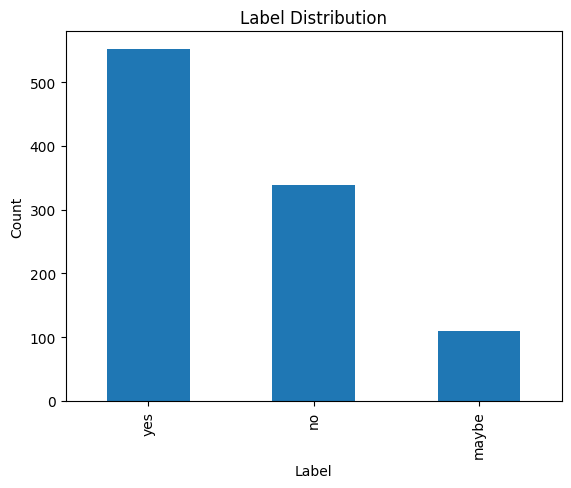

In [10]:
import matplotlib.pyplot as plt


df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

We can see that the data set shows a slight imbalance, with yes forming 55.2%, no forming 33.8% and maybe forming 11% of the samples.

Already, we can extract quite a lot of insights from this.

The dominance of the yes label appearing more frequently than no or maybe might bias a model toward predicting positive outcomes.

But on the opposite side, the maybe label is significantly under represented. Models can become biased towards predicting yes or no while underperforming on maybe due to limited samples. THis can be especially important if maybe is a meaningful and decision critical categry, especially in medical contexts!

Practically speaking, we could also see a lower recall value for maybe, inflated accuracy if a model ignores the minority class, and decision boundary bias towards majority classes yes and no.

I will talk about methods of handling this later. (weights, smote, resample)




In [11]:
df['q_len'] = df['question'].apply(lambda x: len(x.split()))
df['context_len'] = df['context'].apply(lambda x: len(x.split()))

df[['q_len', 'context_len']].describe()

,q_len,context_len
count,1000.000000,1000.000000
mean,12.913000,200.207000
std,4.100518,51.846429
min,3.000000,49.000000
25%,10.000000,166.750000
50%,13.000000,200.500000
75%,15.000000,228.000000
max,31.000000,398.000000


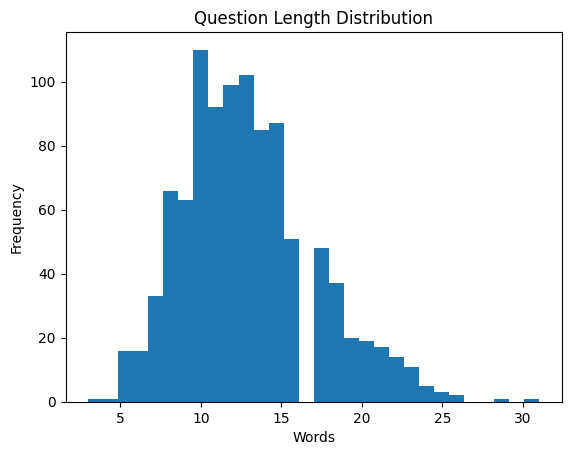

In [12]:
plt.hist(df['q_len'], bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

m

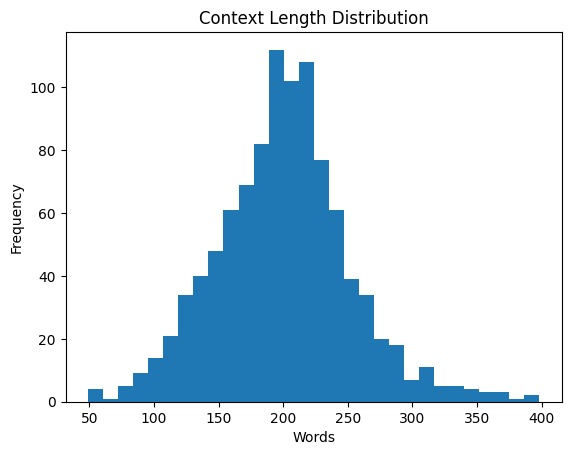

In [13]:
plt.hist(df['context_len'], bins=30)
plt.title("Context Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

There is a big disparity between question length and context length. 

With contexts being a lot larger, which hints that models need to filter out relevant information from noisy input

transformers, handling the input , errors?

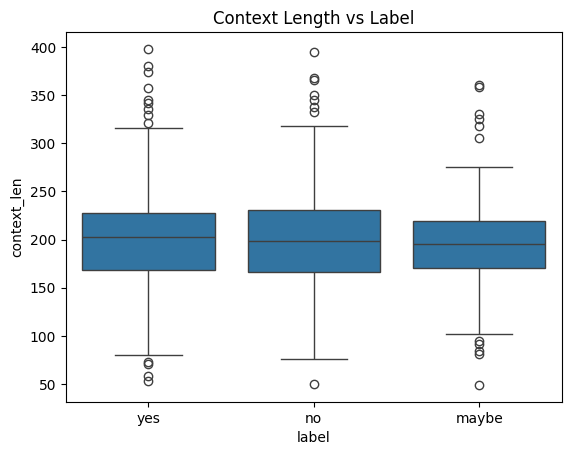

In [14]:
import seaborn as sns

sns.boxplot(x='label', y='context_len', data=df)
plt.title("Context Length vs Label")
plt.show()

NOt very interesting? need to reform

In [15]:
df['q_start'] = df['question'].apply(lambda x: x.split()[0].lower())
df['q_start'].value_counts().head(10)

q_start
does            196
is              191
can              83
do               80
are              68
the              20
should           17
could             6
has               4
preoperative      4
Name: count, dtype: int64

When we do this kind of frequency analysis (looking at the first word of each question), a clear pattern emerges in the question set. They follow a binary question structure "is" and "does", which suggests that a classification based approach is suitable.

not interesting?

In [26]:
df.isnull().sum()

question       0
context        0
label          0
q_len          0
context_len    0
q_start        0
dtype: int64

Its a complete data set with no missing values. Not much need to impute or remove rows?

In [27]:
import re

df['has_number'] = df['context'].apply(lambda x: bool(re.search(r'\d', x)))

df.groupby('label')['has_number'].mean()

label
maybe    0.981818
no       0.982249
yes      0.981884
Name: has_number, dtype: float64

Here we are checking if a context contains numerical values. This is important as we are looking for statistics, mainly percentages and measurements. These can be harder to interpret as they add reasoning complexity, which can affect model performance.